In [1]:
import os
import pathlib
import torch
import logging
import warnings
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import lightning as L
import numpy as np
import pickle

import sys
sys.path.append('..')

# Suppress other common warnings
warnings.filterwarnings('ignore', category=UserWarning)

# Specify where you want model weights/datasets to be saved
DATA_PATH = r"C:\Users\danwillett\Code\geofms\data"

# Set up environment variables that are used by HuggingFace
os.environ["HF_HOME"] = os.path.join(DATA_PATH, "hfhome")
os.environ["HF_HUB_CACHE"] = os.path.join(DATA_PATH, "hub")
os.environ["HF_DATASETS_CACHE"] = os.path.join(DATA_PATH, "datasets")
os.environ["TRANSFORMERS_CACHE"] = os.path.join(DATA_PATH, "transformers")

output_dir = '../checkpoints/terratorch_9x9_time_unfreeze_weights_bias_3'

## 1. Prep Dataset, Filtering, & Data Module

Define a dataset that loads radar, dem and precipitation data from the pickle file

In [2]:
class RadarDEMDataset(Dataset):
    
    DBZ_MIN = -32.0
    DBZ_MAX = 70.0
    
    def __init__(self, samples, dem_path='./preserve_dem_10m_utm.tif', patch_size_m=4620, augment=False, aug_prob=0.5):
        self.samples = samples
        self.patch_size_m = patch_size_m
        self.augment = augment
        self.aug_prob = aug_prob
        
        # Load DEM once into memory (if provided)
        self.dem = None
        if dem_path:
            import rioxarray as rxr
            print(f"  Loading DEM from {dem_path}...")
            dem_data = rxr.open_rasterio(dem_path)
            self.dem = dem_data.values  # (1, H, W) numpy array
            self.dem_x = dem_data.x.values
            self.dem_y = dem_data.y.values
            self.dem_resolution = abs(dem_data.rio.resolution()[0])
            print(f"  ✓ DEM loaded: shape={self.dem.shape}")
    
    def __len__(self):
        return len(self.samples)
    
    def _extract_dem_patch(self, station_lat, station_lon):
        """Extract DEM patch centered on station (on-the-fly)"""
        from pyproj import Transformer
        
        transformer = Transformer.from_crs('EPSG:4326', 'EPSG:32610', always_xy=True)
        station_x, station_y = transformer.transform(station_lon, station_lat)
        
        patch_pixels = int(self.patch_size_m / self.dem_resolution)
        half_pixels = patch_pixels // 2
        
        x_idx = np.abs(self.dem_x - station_x).argmin()
        y_idx = np.abs(self.dem_y - station_y).argmin()
        
        x_start = max(0, x_idx - half_pixels)
        x_end = x_start + patch_pixels
        y_start = max(0, y_idx - half_pixels)
        y_end = y_start + patch_pixels
        
        if x_end > len(self.dem_x):
            x_end = len(self.dem_x)
            x_start = max(0, x_end - patch_pixels)
        if y_end > len(self.dem_y):
            y_end = len(self.dem_y)
            y_start = max(0, y_end - patch_pixels)
        
        patch = self.dem[:, y_start:y_end, x_start:x_end].copy()
        
        if patch.shape[1] != patch_pixels or patch.shape[2] != patch_pixels:
            padded = np.zeros((1, patch_pixels, patch_pixels), dtype=patch.dtype)
            h, w = patch.shape[1], patch.shape[2]
            padded[:, :h, :w] = patch
            patch = padded
        
        return patch
    
    def _process_radar(self, radar_patch, radar_indices):
        """
        Process radar with temporal awareness channels.
        Returns: (48, 256, 256) - 12 radar + 12 mask + 12 tpos + 12 deltas
        """
        radar_arr = radar_patch.copy()

        radar_arr[radar_arr == -9999.0] = self.DBZ_MIN
        radar_arr = np.where(np.isnan(radar_arr), self.DBZ_MIN, radar_arr)
        
        radar_norm = (radar_arr - self.DBZ_MIN) / (self.DBZ_MAX - self.DBZ_MIN)
        radar_norm = np.clip(radar_norm, 0, 1)
        
        mask = np.ones_like(radar_norm)

        for i, ridx in enumerate(radar_indices):
            if ridx is None:
                mask[i, :, :, :] = 0.0
                radar_norm[i, :, :, :] = 0.0

        # Convert to tensors
        radar_t = torch.from_numpy(radar_norm).float()  # (12, 40, 5, 5)
        mask_t = torch.from_numpy(mask).float()          # (12, 40, 5, 5)
        
        # === TAKE MAX OVER Z DIMENSION FIRST ===
        radar_maxz, _ = torch.max(radar_t, dim=1)  # (12, 5, 5)
        mask_maxz, _ = torch.max(mask_t, dim=1)    # (12, 5, 5)

        # ---- Build temporal positional channels ----
        # Now shape is (12, 5, 5)
        t_pos = torch.zeros_like(radar_maxz)
        for i in range(12):
            t_pos[i] = i / 11.0   # normalized 0..1

        # Stack all channels: (48, 5, 5)
        radar_all = torch.cat([radar_maxz, mask_maxz, t_pos], dim=0)

        # Upscale to 256x256
        radar_up = F.interpolate(
            radar_all.unsqueeze(0),
            size=(256, 256),
            mode='nearest'
        ).squeeze(0)

        return radar_up  # (36, 256, 256)
    
    def _process_dem(self, dem_patch):
        """Process DEM: NaN → resize to 256×256"""
        dem_arr = dem_patch.copy()
        
        if dem_arr.ndim == 2:
            dem_arr = dem_arr[np.newaxis, :, :]
        
        dem_arr = np.where(np.isnan(dem_arr), 0.0, dem_arr)
        dem_t = torch.from_numpy(dem_arr).float()
        
        # Resize to 256×256 (handles any input size)
        if dem_t.shape[-1] != 256 or dem_t.shape[-2] != 256:
            dem_t = F.interpolate(
                dem_t.unsqueeze(0), 
                size=(256, 256), 
                mode='bilinear', 
                align_corners=False
            ).squeeze(0)
        
        return dem_t  # (1, 256, 256)
    
    def __getitem__(self, idx):
        s = self.samples[idx]
        radar_patch = s['radar_patch'].copy()  # (12, 40, 9, 9) for 9x9 patches
        
        # === Random crop from 9×9 to 5×5 ===
        input_size = radar_patch.shape[-1]  # 9 for 9x9, 5 for legacy
        output_size = 5
        
        if input_size > output_size:
            max_offset = input_size - output_size  # = 4
            
            if self.augment and np.random.rand() < self.aug_prob:
                # Random crop during training
                offset_y = np.random.randint(0, max_offset + 1)
                offset_x = np.random.randint(0, max_offset + 1)
            else:
                # Center crop during validation
                offset_y = max_offset // 2
                offset_x = max_offset // 2
            
            # Where gauge ends up in the cropped 5×5
            center_pos = input_size // 2  # = 4 for 9×9
            gauge_y = center_pos - offset_y
            gauge_x = center_pos - offset_x
            
            # Crop radar from 9×9 to 5×5
            radar_patch = radar_patch[:, :, offset_y:offset_y+output_size, offset_x:offset_x+output_size]
        else:
            offset_y, offset_x = 0, 0
            gauge_y, gauge_x = 2, 2  # Center of 5×5
        
        radar_t = self._process_radar(radar_patch, s.get("radar_indices"))
        
        # Extract DEM on-the-fly with same offset
        if self.dem is not None:
            dem_patch_full = self._extract_dem_patch(s['station_lat'], s['station_lon'])
            # Downsample to input_size, then crop with same offset
            if input_size > output_size:
                dem_t_full = torch.from_numpy(dem_patch_full).float()
                dem_t_sized = F.interpolate(dem_t_full.unsqueeze(0), size=(input_size, input_size), mode='bilinear', align_corners=False).squeeze(0)
                dem_patch = dem_t_sized[:, offset_y:offset_y+output_size, offset_x:offset_x+output_size].numpy()
            else:
                dem_patch = dem_patch_full
        elif 'dem_patch' in s and s['dem_patch'] is not None:
            dem_patch = s['dem_patch']
        else:
            dem_patch = np.zeros((1, 264, 264))
        
        dem_t = self._process_dem(dem_patch)

        image = {
            "DEM": dem_t,      # (1, 256, 256)
            "RADAR": radar_t   # (36, 256, 256)
        }

        target_value = np.log1p(s['hourly_precip_mm'])
    
        # Create 5x5 mask with target at gauge position
        mask = torch.full((5, 5), -9999.0, dtype=torch.float32)  # Ignore value
        mask[gauge_y, gauge_x] = target_value  # Target at actual gauge position!
        
        return {
            'image': image,    # ← TerraTorch expects this key!
            'mask': mask,
        }


In [3]:
# Filters

def filter_biased_extremes(samples):
    OVERESTIMATING_STATIONS = [
    'Dangermond_Bunker Hill', 'Dangermond_Cistern', 'Dangermond_Cojo HQ', 'Dangermond_Jalachichi','Dangermond_Repeator'  
    ]
    UNDERESTIMATING_STATIONS = [
        'Dangermond_Cojo Gate', 'Dangermond_Sutter'
    ]

    filtered = []
    removed = []

    for sample in samples:
        station_name = sample['station_name']
        target = sample['hourly_precip_mm']
        radar = sample['radar_patch']
        max_dbz = np.nanmax(radar)
        # Overestimating stations: Remove extreme high values
        # (sensor flooding - can't distinguish droplet sizes)
        if station_name in OVERESTIMATING_STATIONS:
            if target > 25.0:  # Very heavy rain
                removed.append(f"{target:.1f}mm precipitation (overestimate)")
                continue
             # Filter out
            if max_dbz > 30.0 and target < 0.3:  # Radar detects storm but gauge reads low
                removed.append(f"{target:.1f}mm precipitation (underestimate)")
                continue
    
        # Underestimating stations: Remove cases where radar says heavy but gauge says light
        # (sensor saturated/clogged)
        if station_name in UNDERESTIMATING_STATIONS:
            if max_dbz > 30.0 and target < 0.3:  # Radar detects storm but gauge reads low
                removed.append(f"{target:.1f}mm precipitation (underestimate)")
                continue
                 # Filter out
        filtered.append(sample)

    print(f"✓ Filtered {len(removed)} samples")
    
    return filtered

def filter_bad_samples(samples):
    """Filter bad samples including ground clutter"""
    filtered = []
    removed = []
    
    for sample in samples:
        target = sample['hourly_precip_mm']
        radar = sample['radar_patch']
        max_dbz = np.nanmax(radar)

        if target > 40.0:
            removed.append(f"{target:.1f}mm precipitation (sensor error)")
            continue
        
        # EXISTING: Remove radar-gauge mismatch (high rain, low radar)
        if target > 5.0 and max_dbz < 20.0:
            removed.append(f"{target:.1f}mm @ {max_dbz:.1f}dBZ (radar miss)")
            continue

        
        # If dBZ > 50 but rain < 2mm, it's likely clutter
        if max_dbz > 50.0 and target < 2.0:
            removed.append(f"{target:.1f}mm @ {max_dbz:.1f}dBZ (ground clutter)")
            continue
        
        # NEW: Remove extreme dBZ (likely always clutter)
        if max_dbz > 60.0:
            removed.append(f"{target:.1f}mm @ {max_dbz:.1f}dBZ (extreme dBZ)")
            continue
            
        filtered.append(sample)
    
    print(f"✓ Filtered {len(removed)} samples")
    
    
    return filtered

def filter_suspect_station_days(samples):
    """
    Filter out samples from station-days where the station recorded ZERO
    but other stations had significant rain (likely sensor issue).
    
    Keep samples if:
    1. Station had SOME rain that day (sensor was working), OR
    2. All stations had low rain that day (genuinely dry)
    """
    # First pass: calculate daily totals per station
    daily_totals = {}
    for sample in samples:
        station = sample.get('station_name', 'Unknown')
        hour_str = str(sample.get('hour_start', ''))
        date = hour_str[:10]
        precip = sample['hourly_precip_mm']
        
        key = (station, date)
        if key not in daily_totals:
            daily_totals[key] = 0
        daily_totals[key] += precip
    
    # Calculate daily network average (excluding each station)
    date_totals = {}
    for (station, date), total in daily_totals.items():
        if date not in date_totals:
            date_totals[date] = []
        date_totals[date].append((station, total))
    
    # Identify suspect station-days
    suspect_station_days = set()
    for date, station_data in date_totals.items():
        for station, total in station_data:
            if total == 0:  # Station had zero all day
                # Calculate average of OTHER stations
                others = [t for s, t in station_data if s != station]
                others_with_rain = sum(1 for t in others if t > 2.0)
                if len(others) >= 5 and others_with_rain >= 9 and np.mean(others) > 15:  # Others had significant rain
                    suspect_station_days.add((station, date))
    
    print(f"Identified {len(suspect_station_days)} suspect station-days")

    # Filter samples
    filtered = []
    removed_count = 0
    
    for sample in samples:
        station = sample.get('station_name', 'Unknown')
        hour_str = str(sample.get('hour_start', ''))
        date = hour_str[:10]
        
        if (station, date) in suspect_station_days:
            removed_count += 1
            continue
        
        filtered.append(sample)
    
    print(f"✓ Removed {removed_count} samples from suspect station-days")
    
    # Show which station-days were removed
    station_day_counts = {}
    for station, date in suspect_station_days:
        short = station.replace('Dangermond_', '')
        if short not in station_day_counts:
            station_day_counts[short] = []
        station_day_counts[short].append(date)
    
    return filtered


In [4]:
# Samplers
from torch.utils.data import WeightedRandomSampler

def create_heavy_rain_sampler(samples):
    """
    Heavily oversample the rare heavy rain events.
    With only 4.5% heavy rain, we need aggressive weights!
    """
    targets = np.array([s['hourly_precip_mm'] for s in samples])
    
    # Create weights based on precipitation intensity
    weights = np.ones(len(targets))
    
    # Zero/trace rain: undersample slightly
    weights[targets < 0.1] = 0.5
    
    # Light rain (0.1-2mm): normal weight
    weights[(targets >= 0.1) & (targets < 2)] = 1.0
    
    # Moderate rain (2-5mm): slight oversample
    weights[(targets >= 2) & (targets < 5)] = 2.0
    
    # Heavy rain (5-15mm): moderate oversample
    weights[(targets >= 5) & (targets < 15)] = 5.0
    
    # Very heavy rain (15-40mm): heavier oversample
    weights[(targets >= 15) & (targets <= 40)] = 10.0
    
    # Normalize
    weights = weights / weights.sum() * len(weights)
    
    sampler = WeightedRandomSampler(
        weights=weights,
        num_samples=len(weights),
        replacement=True
    )
    
    # Report effective distribution
    effective_pct = weights / weights.sum() * 100
    print(f"\n{'='*50}")
    print(f"WEIGHTED SAMPLER CREATED")
    print(f"{'='*50}")
    print(f"Category          | Original | Effective")
    print(f"------------------|----------|----------")
    print(f"Zero rain         | {(targets==0).mean()*100:5.1f}%   | {effective_pct[targets==0].sum():5.1f}%")
    print(f"Light (0-2mm)     | {((targets>0)&(targets<2)).mean()*100:5.1f}%   | {effective_pct[(targets>0)&(targets<2)].sum():5.1f}%")
    print(f"Moderate (2-5mm)  | {((targets>=2)&(targets<5)).mean()*100:5.1f}%   | {effective_pct[(targets>=2)&(targets<5)].sum():5.1f}%")
    print(f"Heavy (5-10mm)    | {((targets>=5)&(targets<10)).mean()*100:5.1f}%   | {effective_pct[(targets>=5)&(targets<10)].sum():5.1f}%")
    print(f"V.Heavy (>10mm)   | {(targets>=10).mean()*100:5.1f}%   | {effective_pct[targets>=10].sum():5.1f}%")
    print(f"{'='*50}")
    
    return sampler


In [ ]:
class RadarDEMDataModule(L.LightningDataModule):
    def __init__(self, pickle_path: str, weight_sampler=None, batch_size=32, num_workers=0):
        super().__init__()
        self.pickle_path = pickle_path
        self.batch_size = batch_size
        self.num_workers = num_workers

        self.train_samples = None
        self.val_samples = None
        
        self.weight_sampler = weight_sampler
        self.train_sampler = None

    def prepare_data(self):
        # no heavy downloads
        pass

    def setup(self, stage=None):

        # load data from pickle
        data = pickle.load(open(self.pickle_path, "rb"))
        train_samples, val_samples = data["train"], data["val"]
        
        # filter samples that may have sensor error or radar issues
        train_samples = filter_biased_extremes(train_samples) 
        val_samples = filter_biased_extremes(val_samples)

        train_samples = filter_bad_samples(train_samples) 
        val_samples = filter_bad_samples(val_samples)

        train_samples = filter_suspect_station_days(train_samples) 
        val_samples = filter_suspect_station_days(val_samples)

        self.train_ds = RadarDEMDataset(train_samples, patch_size_m=4620, augment=True, aug_prob=0.5)
        self.val_ds = RadarDEMDataset(val_samples, patch_size_m=4620, augment=False)

        # add a weight sampler to training data if configured
        if self.weight_sampler is not None:
            self.train_sampler = self.weight_sampler(train_samples)
        

    def train_dataloader(self):
        return DataLoader(self.train_ds, batch_size=self.batch_size, shuffle=True, num_workers=self.num_workers, pin_memory=True)

    def val_dataloader(self):
        return DataLoader(self.val_ds, batch_size=self.batch_size, shuffle=False, num_workers=self.num_workers, pin_memory=True)
        

In [6]:
# Create datamodule
datamodule = RadarDEMDataModule(
    pickle_path='../deep_learning/radar_gauge_dataset_9x9.pkl', 
    weight_sampler=create_heavy_rain_sampler,
    batch_size=8
    )



## 2. Define Decoder

In [7]:
class SpatialPrecipitationDecoder(nn.Module):
    """
    Decodes spatial features to a 5×5 precipitation map.
    Compatible with TerraTorch's multi-scale feature lists.
    """
    includes_head = False

    def __init__(self, in_channels=192, target_size=5, output_bias=2.0):
        super().__init__()
        
        self.out_channels = 1
        
        self.conv1 = nn.Conv2d(in_channels, 128, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(128)
        
        self.conv2 = nn.Conv2d(128, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        self.conv3 = nn.Conv2d(64, 32, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(32)
        
        self.conv_out = nn.Conv2d(32, 1, kernel_size=1)
        self.final_pool = nn.AdaptiveAvgPool2d((target_size, target_size))

        with torch.no_grad():
            self.conv_out.bias.data.fill_(output_bias)
        
    def forward(self, x):
        """
        Input: List of feature tensors OR single tensor
        Output: (batch, 5, 5) - precipitation map
        """
        # === HANDLE LIST INPUT FROM TERRATORCH ===
        if isinstance(x, list):
            # Take the last feature map (highest-level features)
            x = x[-1]
        
        # If features are (batch, patches, channels), reshape to spatial
        if x.dim() == 3:
            batch_size, num_patches, feat_dim = x.shape
            H = W = int(num_patches ** 0.5)  # e.g., 256 patches → 16×16
            x = x.transpose(1, 2).reshape(batch_size, feat_dim, H, W)
        
        # Now x should be (batch, channels, H, W)
        x = F.relu(self.bn1(self.conv1(x)))  # (B, 128, H, W)
        x = F.relu(self.bn2(self.conv2(x)))  # (B, 64, H, W)
        x = F.relu(self.bn3(self.conv3(x)))  # (B, 32, H, W)
        
        x = self.conv_out(x)  # (B, 1, H, W)
        x = self.final_pool(x)  # (B, 1, 5, 5)
        
        # DON'T squeeze - TerraTorch expects (B, C, H, W) output
        return x  # (B, 1, 5, 5)

## 3. Define Task

In [8]:
from terratorch.tasks import PixelwiseRegressionTask

task = PixelwiseRegressionTask(

    # Define your model
    model_factory="EncoderDecoderFactory", # TerraTorch's EncoderDecoderFactory, where we found our models
    model_args={
        'backbone': 'terramind_v1_tiny', 
        'backbone_pretrained': True, # Train from pre-trained weights?
        'backbone_modalities': ["DEM", {"RADAR": 36}],
        'backbone_merge_method': 'concat',
        'decoder': SpatialPrecipitationDecoder(in_channels=384, output_bias=3), # Chosen decoder for classification
        'rescale': False,
    },

    # What would you like to train?
    freeze_backbone=True, # Do not update terramind weights
    freeze_decoder=False, # Train the decoder

    # Optionally, change hyperparameters from the defaults
    loss='mse',
    lr=1e-5,
    
    ignore_index=-9999,
    scheduler='ReduceLROnPlateau'
)

# === MANUALLY UNFREEZE JUST THE RADAR EMBEDDING ===
backbone = task.model.encoder  # Access the TerraMind backbone

# Unfreeze RADAR embedding only
for param in backbone.encoder_embeddings['RADAR'].parameters():
    param.requires_grad = True


# After unfreezing RADAR (line 33), add:

print("\n=== OPTIMIZER CHECK ===")

# Manually configure optimizers to see what Lightning will use
optimizers = task.configure_optimizers()

# Extract the optimizer (might be dict or list)
if isinstance(optimizers, dict):
    opt = optimizers['optimizer']
elif isinstance(optimizers, list):
    opt = optimizers[0]
else:
    opt = optimizers

# Check if RADAR params are in optimizer
radar_params = list(backbone.encoder_embeddings['RADAR'].parameters())
radar_param_ids = {id(p) for p in radar_params}

opt_param_ids = {id(p) for group in opt.param_groups for p in group['params']}

radar_in_opt = radar_param_ids.intersection(opt_param_ids)

print(f"RADAR params: {len(radar_params)}")
print(f"RADAR params in optimizer: {len(radar_in_opt)}/{len(radar_params)}")

if len(radar_in_opt) == 0:
    print("❌ RADAR PARAMS NOT IN OPTIMIZER! They won't train!")
elif len(radar_in_opt) < len(radar_params):
    print("⚠️ Only SOME RADAR params in optimizer!")
else:
    print("✓ All RADAR params in optimizer - should train correctly!")

# print("\n" + "="*60)
# print("SELECTIVE UNFREEZING")
# print("="*60)

# # Verify what's trainable
# trainable_params = sum(p.numel() for p in task.parameters() if p.requires_grad)
# total_params = sum(p.numel() for p in task.parameters())

# print(f"Trainable parameters: {trainable_params:,}")
# print(f"Total parameters: {total_params:,}")
# print(f"Trainable %: {100*trainable_params/total_params:.1f}%")

# print(backbone.encoder_embeddings)
# # Show which parts are trainable
# print("\nRADAR embedding trainable:", 
#       any(p.requires_grad for p in backbone.encoder_embeddings['RADAR'].parameters()))


c:\Users\danwillett\AppData\Local\anaconda3\envs\torch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:httpx:HTTP Request: HEAD https://huggingface.co/ibm-esa-geospatial/TerraMind-1.0-tiny/resolve/main/TerraMind_v1_tiny.pt "HTTP/1.1 302 Found"



=== OPTIMIZER CHECK ===
RADAR params: 2
RADAR params in optimizer: 2/2
✓ All RADAR params in optimizer - should train correctly!


## 4. Train!

In [9]:
from lightning.pytorch.loggers import WandbLogger
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint, RichProgressBar, LearningRateMonitor

# Auto-detect best precision based on available hardware
if torch.cuda.is_available():
    precision = "16-mixed"  # CUDA supports mixed precision well
elif torch.backends.mps.is_available():
    precision = "32"  # MPS has limited 16-bit support
else:
    precision = "32"  # CPU doesn't benefit from mixed precision


# Initialize callbacks
# Save the best and the last model
checkpoint_callback = ModelCheckpoint(
    dirpath=output_dir,  # ← ADD THIS! Explicit path
    filename='best-{epoch:02d}-{val_loss:.4f}',
    monitor=task.monitor, 
    save_top_k=1, 
    save_last=True
    )
# Stop training if validation metrics stop improving for a certain number of epochs
early_stopping_callback = EarlyStopping(
    monitor=task.monitor, min_delta=0.00, patience=20)

# Set this to None so we can load the best model from checkpoint later
checkpoint_callback.best_model_path = None

In [10]:
# Check your progress and results during training using Weights and Biases.
# You'll have to make an account but it's very useful.
# Just click the link it gives you to watch your training progress plotted in real time.
import wandb
wandb.login(key="8505008f4338b9d8ad58dd6dd296b112a749e5c5")
wandb_logger = WandbLogger(log_model="all")

# Define your Trainer
trainer = Trainer(
    accelerator="auto",
    devices=1,  # Number of GPUs. Interactive mode recommended with 1 device
    precision=precision,  # Mac MPS has limited support for 16-bit floats
    # precision="16-mixed", # Use 16-bit floats as opposed to 32-bit (higher precision) when it's safe to save on time and memory
    callbacks=[
        RichProgressBar(),
        checkpoint_callback,
        early_stopping_callback,
        LearningRateMonitor(logging_interval="epoch"),
    ],
    logger=wandb_logger,
    max_epochs=100,  # Train for up to 100 epochs
    default_root_dir=output_dir,  # where checkpoints/logs go.
    log_every_n_steps=1,
    check_val_every_n_epoch=1  # How frequently to calcualte validation performance
)

# Fit your model!
_ = trainer.fit(model=task, datamodule=datamodule)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\danwillett\_netrc
wandb: Currently logged in as: daniel-willett2 (daniel-willett2-university-of-california-santa-barbara) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


✓ Filtered 1639 samples
✓ Filtered 584 samples


C:\Users\danwillett\AppData\Local\Temp\ipykernel_31516\2350778347.py:18: RuntimeWarning: All-NaN slice encountered
  max_dbz = np.nanmax(radar)


✓ Filtered 147 samples
✓ Filtered 62 samples
Identified 22 suspect station-days
✓ Removed 360 samples from suspect station-days
Identified 12 suspect station-days
✓ Removed 157 samples from suspect station-days
  Loading DEM from ./preserve_dem_10m_utm.tif...


C:\Users\danwillett\AppData\Local\Temp\ipykernel_31516\2350778347.py:51: RuntimeWarning: All-NaN slice encountered
  max_dbz = np.nanmax(radar)


...

┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                   ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ PixelWiseModel         │  7.7 M │ train │
│ 1 │ criterion     │ IgnoreIndexLossWrapper │      0 │ train │
│ 2 │ train_metrics │ MetricCollection       │      0 │ train │
│ 3 │ val_metrics   │ MetricCollection       │      0 │ train │
│ 4 │ test_metrics  │ ModuleList             │      0 │ train │
└───┴───────────────┴────────────────────────┴────────┴───────┘

Trainable params: 2.3 M                                                                                            
Non-trainable params: 5.4 M                                                                                        
Total params: 7.7 M                                                                                                
Total estimated model params size (MB): 30                                                                         
Modules in train mode: 223                                                                                         
Modules in eval mode: 0

c:\Users\danwillett\AppData\Local\anaconda3\envs\torch\Lib\site-packages\rich\live.py:231: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

c:\Users\danwillett\AppData\Local\anaconda3\envs\torch\Lib\site-packages\lightning\pytorch\trainer\connectors\data_
connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.

c:\Users\danwillett\AppData\Local\anaconda3\envs\torch\Lib\site-packages\lightning\pytorch\trainer\connectors\data_
connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.

In [11]:
# Load the best model from checkpoint
if checkpoint_callback.best_model_path is not None:
    # If the best model path is not None, use it
    best_model_path = checkpoint_callback.best_model_path
else:
    # If the best model path is None, use a default path (must already exist!)
    best_model_path = r"checkpoints\terratorch_5x5_time_unfreeze\best-epoch=16-val_loss=0.0000.ckpt"
print(f"Best model saved at: {best_model_path}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Best model saved at: C:\Users\danwillett\Code\geofms\checkpoints\terratorch_9x9_time_unfreeze_weights_bias_3\best-epoch=32-val_loss=0.0000.ckpt


In [15]:
# After training completes, load best model and evaluate
from terratorch.tasks import PixelwiseRegressionTask
import numpy as np

import os
from pathlib import Path

checkpoint_dir = Path('../checkpoints/terratorch_9x9_time_unfreeze_weights)bias_3')


if checkpoint_callback.best_model_path is not None:
    best_model_path = checkpoint_callback.best_model_path
    print(f"Using callback path: {best_model_path}")
else:
    # Find the best checkpoint manually
    checkpoint_files = list(checkpoint_dir.glob('best-*.ckpt'))
    
    if checkpoint_files:
        # Get the most recent best checkpoint
        best_model_path = str(max(checkpoint_files, key=os.path.getmtime))
        print(f"Found checkpoint: {best_model_path}")
    else:
        # Fall back to last checkpoint
        last_ckpt = checkpoint_dir / 'last.ckpt'
        if last_ckpt.exists():
            best_model_path = str(last_ckpt)
            print(f"Using last checkpoint: {best_model_path}")
        else:
            raise FileNotFoundError(f"No checkpoints found in {checkpoint_dir}")

print(f"Loading model from: {best_model_path}")

# === LOAD THE MODEL ===
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

best_model = PixelwiseRegressionTask.load_from_checkpoint(
    best_model_path
)
best_model.eval()
best_model.to(device)

print("✓ Model loaded successfully!")

# Reload datamodule
datamodule.setup()

# Collect predictions
all_preds_log = []
all_targets_log = []

print("Running evaluation...")
with torch.no_grad():
    for batch in datamodule.val_dataloader():
        # Move image to device
        image_gpu = {k: v.to(device) for k, v in batch['image'].items()}
        
        # Get prediction
        model_output = best_model.model(image_gpu)  # Returns ModelOutput object
        pred = model_output.output  # ← EXTRACT the actual tensor!
        
        # pred shape: (B, 1, 256, 256) in log space
        
        # Extract center pixel prediction
        pred_center = pred[:, 2, 2].cpu().numpy()
        target_center = batch['mask'][:, 2, 2].numpy()
        
        all_preds_log.extend(pred_center)
        all_targets_log.extend(target_center)

# Filter out ignore values
preds_log = np.array(all_preds_log)
targets_log = np.array(all_targets_log)
valid_mask = targets_log > -9000

preds_log_valid = preds_log[valid_mask]
targets_log_valid = targets_log[valid_mask]

# === CONVERT FROM LOG SPACE TO REAL MM/HR ===
preds_mm = np.expm1(preds_log_valid)
targets_mm = np.expm1(targets_log_valid)

# Calculate metrics in REAL space
mae_real = np.mean(np.abs(targets_mm - preds_mm))
r2_real = 1 - np.sum((targets_mm - preds_mm)**2) / np.sum((targets_mm - targets_mm.mean())**2)

# Also calculate in log space
mae_log = np.mean(np.abs(preds_log_valid - targets_log_valid))
r2_log = 1 - np.sum((preds_log_valid - targets_log_valid)**2) / np.sum((targets_log_valid - targets_log_valid.mean())**2)

print(f"\n{'='*60}")
print(f"📊 TERRAMIND MODEL EVALUATION")
print(f"{'='*60}")
print(f"\n🔍 REAL MM/HR SPACE (comparable to stacked model):")
print(f"  R²:       {r2_real:.3f}")
print(f"  MAE:      {mae_real:.3f} mm/hr")
print(f"  Pred Max: {preds_mm.max():.2f} mm/hr")
print(f"  Pred Min: {preds_mm.min():.2f} mm/hr")
print(f"  # Pred >5mm: {np.sum(preds_mm > 5)}")

print(f"\n📊 LOG SPACE (what WandB showed):")
print(f"  R²:  {r2_log:.3f}")
print(f"  MAE: {mae_log:.3f}")

print(f"\n🎯 COMPARISON TO BEST STACKED MODEL:")
print(f"  Stacked R²:    0.328")
print(f"  TerraMind R²:  {r2_real:.3f}")
print(f"  Difference:    {r2_real - 0.328:+.3f}")

Using callback path: C:\Users\danwillett\Code\geofms\checkpoints\terratorch_9x9_time_unfreeze_weights_bias_3\best-epoch=32-val_loss=0.0000.ckpt
Loading model from: C:\Users\danwillett\Code\geofms\checkpoints\terratorch_9x9_time_unfreeze_weights_bias_3\best-epoch=32-val_loss=0.0000.ckpt


INFO:httpx:HTTP Request: HEAD https://huggingface.co/ibm-esa-geospatial/TerraMind-1.0-tiny/resolve/main/TerraMind_v1_tiny.pt "HTTP/1.1 302 Found"


✓ Model loaded successfully!
✓ Filtered 1639 samples


C:\Users\danwillett\AppData\Local\Temp\ipykernel_31516\2350778347.py:18: RuntimeWarning: All-NaN slice encountered
  max_dbz = np.nanmax(radar)


✓ Filtered 584 samples
✓ Filtered 147 samples
✓ Filtered 62 samples


C:\Users\danwillett\AppData\Local\Temp\ipykernel_31516\2350778347.py:51: RuntimeWarning: All-NaN slice encountered
  max_dbz = np.nanmax(radar)


Identified 22 suspect station-days
✓ Removed 360 samples from suspect station-days
Identified 12 suspect station-days
✓ Removed 157 samples from suspect station-days
  Loading DEM from ./preserve_dem_10m_utm.tif...
  ✓ DEM loaded: shape=(1, 2763, 2527)
  Loading DEM from ./preserve_dem_10m_utm.tif...
  ✓ DEM loaded: shape=(1, 2763, 2527)

WEIGHTED SAMPLER CREATED
Category          | Original | Effective
------------------|----------|----------
Zero rain         |  58.1%   |  32.4%
Light (0-2mm)     |  32.0%   |  31.4%
Moderate (2-5mm)  |   6.3%   |  14.0%
Heavy (5-10mm)    |   2.6%   |  14.3%
V.Heavy (>10mm)   |   1.1%   |   7.8%
Running evaluation...

📊 TERRAMIND MODEL EVALUATION

🔍 REAL MM/HR SPACE (comparable to stacked model):
  R²:       0.334
  MAE:      0.469 mm/hr
  Pred Max: 7.40 mm/hr
  Pred Min: -0.17 mm/hr
  # Pred >5mm: 13

📊 LOG SPACE (what WandB showed):
  R²:  0.478
  MAE: 0.231

🎯 COMPARISON TO BEST STACKED MODEL:
  Stacked R²:    0.328
  TerraMind R²:  0.334
  Differe

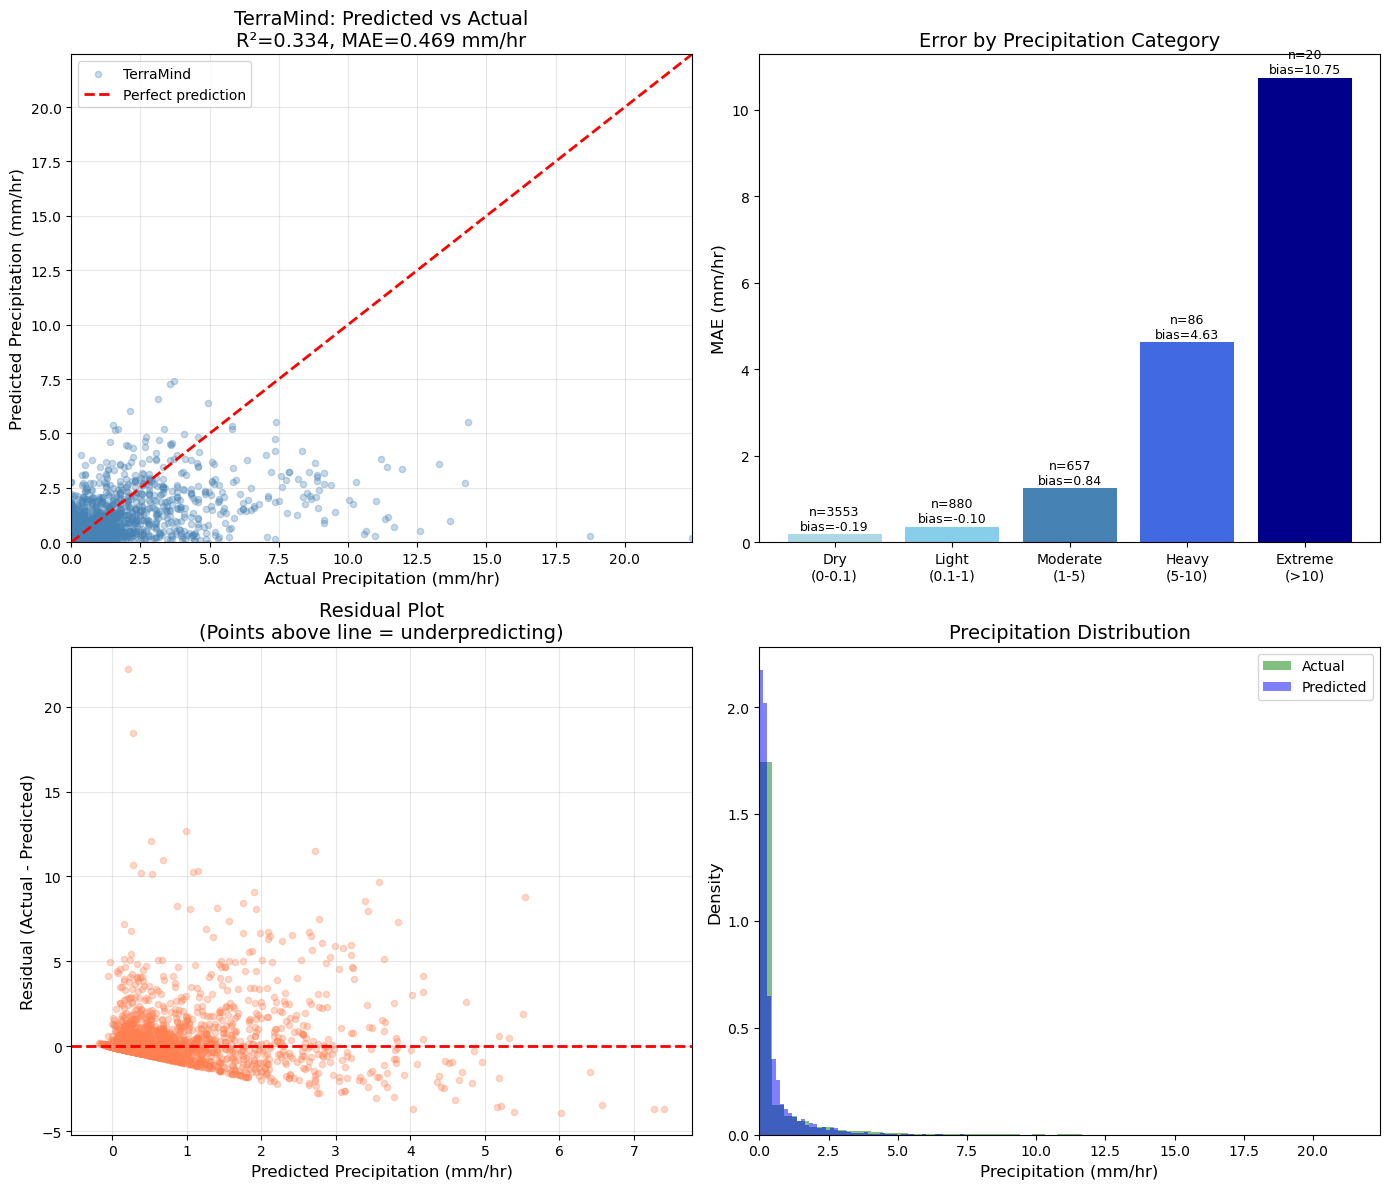


📊 DETAILED ANALYSIS

🎯 Heavy Rain Performance (>5mm):
  Samples: 106
  MAE: 5.783 mm/hr
  Bias: 5.783 mm/hr (underpredicting)
  Predicted >5mm: 4 / 106

📈 Comparison to Stacked Model:
  Metric          | Stacked | TerraMind | Winner
  ------------------------------------------------------------
  R² (real)       | 0.328   | 0.334     | TerraMind
  MAE (real)      | 0.507   | 0.469     | TerraMind
  Pred Max        | 8.19    | 7.40     | Stacked
  Pred >5mm       | 194     | 13       | Stacked


In [16]:
import matplotlib.pyplot as plt
from scipy import stats

# Create figure with multiple plots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# ============================================================
# Plot 1: Scatter Plot
# ============================================================
ax1 = axes[0, 0]
ax1.scatter(targets_mm, preds_mm, alpha=0.3, s=20, c='steelblue', label='TerraMind')
max_val = max(targets_mm.max(), preds_mm.max())
ax1.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect prediction')
ax1.set_xlabel('Actual Precipitation (mm/hr)', fontsize=12)
ax1.set_ylabel('Predicted Precipitation (mm/hr)', fontsize=12)
ax1.set_title(f'TerraMind: Predicted vs Actual\nR²={r2_real:.3f}, MAE={mae_real:.3f} mm/hr', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, max_val])
ax1.set_ylim([0, max_val])

# ============================================================
# Plot 2: Error by Category
# ============================================================
ax2 = axes[0, 1]
categories = ['Dry\n(0-0.1)', 'Light\n(0.1-1)', 'Moderate\n(1-5)', 'Heavy\n(5-10)', 'Extreme\n(>10)']
bounds = [0, 0.1, 1, 5, 10, 100]
maes = []
counts = []
biases = []

for i in range(len(bounds)-1):
    mask = (targets_mm >= bounds[i]) & (targets_mm < bounds[i+1])
    if mask.sum() > 0:
        errors = targets_mm[mask] - preds_mm[mask]
        maes.append(np.mean(np.abs(errors)))
        biases.append(np.mean(errors))  # Positive = underpredicting
        counts.append(mask.sum())
    else:
        maes.append(0)
        biases.append(0)
        counts.append(0)

x_pos = np.arange(len(categories))
bars = ax2.bar(x_pos, maes, color=['lightblue', 'skyblue', 'steelblue', 'royalblue', 'darkblue'])
ax2.set_ylabel('MAE (mm/hr)', fontsize=12)
ax2.set_title('Error by Precipitation Category', fontsize=14)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(categories)

for bar, count, bias in zip(bars, counts, biases):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height + 0.1, 
             f'n={count}\nbias={bias:.2f}', ha='center', fontsize=9)

# ============================================================
# Plot 3: Residual Plot
# ============================================================
ax3 = axes[1, 0]
residuals = targets_mm - preds_mm
ax3.scatter(preds_mm, residuals, alpha=0.3, s=20, c='coral')
ax3.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax3.set_xlabel('Predicted Precipitation (mm/hr)', fontsize=12)
ax3.set_ylabel('Residual (Actual - Predicted)', fontsize=12)
ax3.set_title('Residual Plot\n(Points above line = underpredicting)', fontsize=14)
ax3.grid(True, alpha=0.3)

# ============================================================
# Plot 4: Prediction Distribution
# ============================================================
ax4 = axes[1, 1]
ax4.hist(targets_mm, bins=50, alpha=0.5, label='Actual', color='green', density=True)
ax4.hist(preds_mm, bins=50, alpha=0.5, label='Predicted', color='blue', density=True)
ax4.set_xlabel('Precipitation (mm/hr)', fontsize=12)
ax4.set_ylabel('Density', fontsize=12)
ax4.set_title('Precipitation Distribution', fontsize=14)
ax4.legend()
ax4.set_xlim([0, max(targets_mm.max(), preds_mm.max())])

plt.tight_layout()
plt.savefig('terramind_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# Print detailed statistics
# ============================================================
print(f"\n{'='*60}")
print(f"📊 DETAILED ANALYSIS")
print(f"{'='*60}")

print(f"\n🎯 Heavy Rain Performance (>5mm):")
heavy_mask = targets_mm > 5
if heavy_mask.sum() > 0:
    heavy_mae = np.mean(np.abs(targets_mm[heavy_mask] - preds_mm[heavy_mask]))
    heavy_bias = np.mean(targets_mm[heavy_mask] - preds_mm[heavy_mask])
    print(f"  Samples: {heavy_mask.sum()}")
    print(f"  MAE: {heavy_mae:.3f} mm/hr")
    print(f"  Bias: {heavy_bias:.3f} mm/hr ({'underpredicting' if heavy_bias > 0 else 'overpredicting'})")
    print(f"  Predicted >5mm: {np.sum(preds_mm[heavy_mask] > 5)} / {heavy_mask.sum()}")

print(f"\n📈 Comparison to Stacked Model:")
print(f"  Metric          | Stacked | TerraMind | Winner")
print(f"  {'-'*60}")
print(f"  R² (real)       | 0.328   | {r2_real:.3f}     | {'Stacked' if 0.328 > r2_real else 'TerraMind'}")
print(f"  MAE (real)      | 0.507   | {mae_real:.3f}     | {'Stacked' if 0.507 < mae_real else 'TerraMind'}")
print(f"  Pred Max        | 8.19    | {preds_mm.max():.2f}     | {'Stacked' if 8.19 > preds_mm.max() else 'TerraMind'}")
print(f"  Pred >5mm       | 194     | {np.sum(preds_mm > 5)}       | {'Stacked' if 194 > np.sum(preds_mm > 5) else 'TerraMind'}")

In [20]:
from tqdm import tqdm
from collections import defaultdict

# Ensure model is on GPU and in eval mode
task.model.to(device)
task.model.eval()

# Load test data (use 9x9 version if available)
test_pkl_path = '../deep_learning/radar_gauge_test_daily_9x9.pkl'
with open(test_pkl_path, 'rb') as f:
    test_data = pickle.load(f)

test_samples = test_data['test']
noise_levels = [0.0, 0.1, 0.2, 0.5]

# Create a test dataset using the EXACT same class as training
class TestRadarDEMDataset(RadarDEMDataset):
    """Same preprocessing, but returns hourly samples with daily truth"""
    
    def __getitem__(self, idx):
        s = self.samples[idx]
        radar_patch = s['radar_patch'].copy()
        
        # Center crop from 9×9 to 5×5 (no augmentation for test)
        input_size = radar_patch.shape[-1]
        output_size = 5
        
        if input_size > output_size:
            offset = (input_size - output_size) // 2
            radar_patch = radar_patch[:, :, offset:offset+output_size, offset:offset+output_size]
        
        radar_t = self._process_radar(radar_patch, s.get("radar_indices", []))
        
        # Extract DEM on-the-fly or use pre-extracted
        if self.dem is not None:
            dem_patch_full = self._extract_dem_patch(s['station_lat'], s['station_lon'])
            if input_size > output_size:
                dem_t_full = torch.from_numpy(dem_patch_full).float()
                dem_t_sized = F.interpolate(dem_t_full.unsqueeze(0), size=(input_size, input_size), mode='bilinear', align_corners=False).squeeze(0)
                offset = (input_size - output_size) // 2
                dem_patch = dem_t_sized[:, offset:offset+output_size, offset:offset+output_size].numpy()
            else:
                dem_patch = dem_patch_full
        elif 'dem_patch' in s and s['dem_patch'] is not None:
            dem_patch = s['dem_patch']
        else:
            dem_patch = np.zeros((1, 264, 264))
        
        dem_t = self._process_dem(dem_patch)

        image = {
            "DEM": dem_t,
            "RADAR": radar_t
        }
        
        return {
            'image': image,
            'daily_precip_mm': s['daily_precip_mm'],
            'date': s['date'],
            'station_id': s['station_id'],
            'station_name': s['station_name'],
        }


# Direct iteration (no DataLoader batching issues)
daily_groups = defaultdict(lambda: {'preds': [], 'truth': None, 'name': ''})

test_ds = TestRadarDEMDataset(test_data['test'], dem_path='./preserve_dem_10m_utm.tif', patch_size_m=4620, augment=False)

# During evaluation loop, track raw predictions
all_raw_preds = []
all_clamped_preds = []

with torch.no_grad():
    for i in tqdm(range(len(test_ds)), desc="Test samples"):
        sample = test_ds[i]
        raw = test_data['test'][i]  # Get original for metadata
        
        image_gpu = {k: v.unsqueeze(0).to(device) for k, v in sample['image'].items()}

        #  # === ADD NOISE TO RADAR (insert this line) ===
        # image_gpu['RADAR'] = image_gpu['RADAR'] + torch.randn_like(image_gpu['RADAR']) * 0.2
        
        output = task.model(image_gpu)
        pred_log = output.output[0, 2, 2].item()
        pred_mm_clamped = max(0, np.expm1(pred_log))
        pred_mm_raw = np.expm1(pred_log)

        all_raw_preds.append(pred_mm_raw)
        all_clamped_preds.append(pred_mm_clamped)
        
        key = (raw['date'], raw['station_id'])
        daily_groups[key]['preds'].append(pred_mm_clamped)
        daily_groups[key]['truth'] = raw['daily_precip_mm']
        daily_groups[key]['name'] = raw['station_name']

# Aggregate to daily
preds = []
truths = []
for key, data in daily_groups.items():
    preds.append(sum(data['preds']))
    truths.append(data['truth'])

preds = np.array(preds)
truths = np.array(truths)

r2 = 1 - np.sum((truths - preds)**2) / np.sum((truths - truths.mean())**2)
mae = np.mean(np.abs(preds - truths))

print(f"\nTest set (using RadarDEMDataset preprocessing):")
print(f"  R²:  {r2:.3f}")
print(f"  MAE: {mae:.2f} mm/day")

  Loading DEM from ./preserve_dem_10m_utm.tif...
  ✓ DEM loaded: shape=(1, 2763, 2527)


Test samples: 100%|██████████| 4743/4743 [00:49<00:00, 96.40it/s] 


Test set (using RadarDEMDataset preprocessing):
  R²:  -0.527
  MAE: 16.30 mm/day


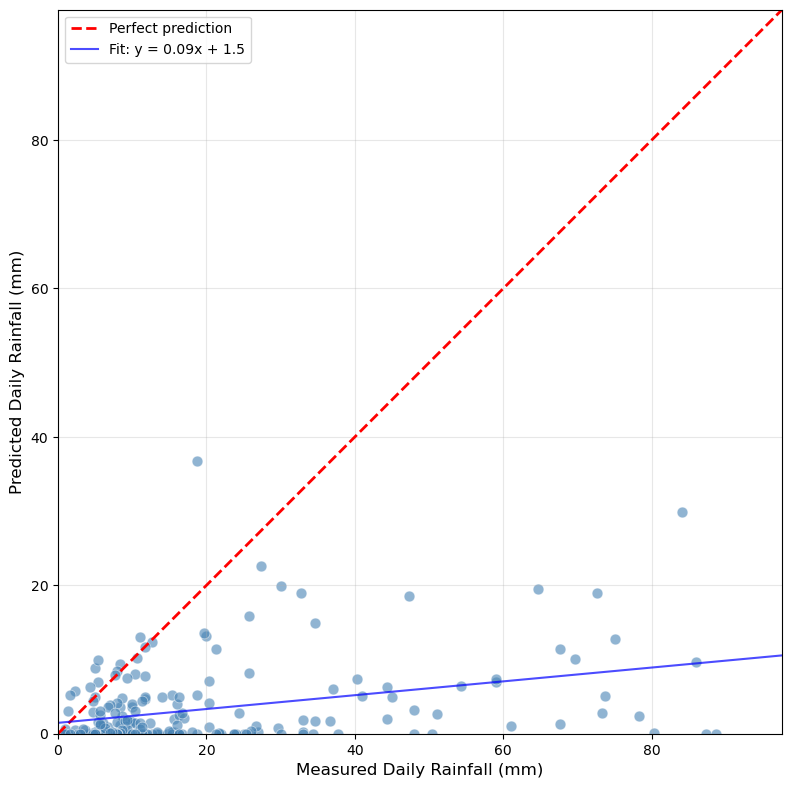


Prediction stats:
  Mean truth: 19.1 mm
  Mean pred:  3.2 mm
  Correlation: 0.341


In [21]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 8))

# Scatter plot
ax.scatter(truths, preds, alpha=0.6, s=60, c='steelblue', edgecolors='white', linewidth=0.5)

# Perfect prediction line
max_val = max(truths.max(), preds.max()) * 1.1
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect prediction')

# Fit line
z = np.polyfit(truths, preds, 1)
p = np.poly1d(z)
ax.plot([0, max_val], [p(0), p(max_val)], 'b-', alpha=0.7, linewidth=1.5, label=f'Fit: y = {z[0]:.2f}x + {z[1]:.1f}')

# Labels
ax.set_xlabel('Measured Daily Rainfall (mm)', fontsize=12)
ax.set_ylabel('Predicted Daily Rainfall (mm)', fontsize=12)
ax.legend(loc='upper left')
ax.set_xlim(0, max_val)
ax.set_ylim(0, max_val)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Also print some stats
print(f"\nPrediction stats:")
print(f"  Mean truth: {truths.mean():.1f} mm")
print(f"  Mean pred:  {preds.mean():.1f} mm")
print(f"  Correlation: {np.corrcoef(truths, preds)[0,1]:.3f}")

In [22]:
from scipy import stats

# Fit: truth = slope * pred + intercept
slope, intercept, r_value, p_value, std_err = stats.linregress(preds, truths)

print("=== LINEAR FIT ANALYSIS ===")
print(f"Fit: truth = {slope:.3f} × pred + {intercept:.2f}")
print(f"Correlation R²: {r_value**2:.3f}")  # How well predictions track with truth
print(f"Standard R²:    {r2:.3f}")          # Your original R²
print(f"Slope: {slope:.3f}")
if slope > 1:
    print(f"  → Model underpredicts by ~{slope:.1f}x")
print(f"Intercept: {intercept:.2f} mm/day")
print(f"P-value: {p_value:.2e}")

# Calibrated predictions
preds_calibrated = slope * preds + intercept
ss_res_cal = np.sum((truths - preds_calibrated)**2)
r2_calibrated = 1 - (ss_res_cal / ss_tot)
mae_calibrated = np.mean(np.abs(preds_calibrated - truths))

print(f"\n=== AFTER CALIBRATION ===")
print(f"R² (calibrated):  {r2_calibrated:.3f}")
print(f"MAE (calibrated): {mae_calibrated:.2f} mm/day")

# Scatter plot with fit line
plt.figure(figsize=(8, 8))
plt.scatter(preds, truths, alpha=0.5, label='Predictions')
plt.plot([0, max(preds)], [intercept, slope*max(preds) + intercept], 'r-', 
         label=f'Fit: y={slope:.2f}x + {intercept:.1f}')
plt.plot([0, max(truths)], [0, max(truths)], 'k--', label='Perfect (y=x)')
plt.xlabel('Predicted (mm/day)')
plt.ylabel('Truth (mm/day)')
plt.title(f'TerraTorch: R²={r2:.3f}, Corr R²={r_value**2:.3f}, Slope={slope:.2f}')
plt.legend()
plt.axis('equal')
plt.show()

=== LINEAR FIT ANALYSIS ===
Fit: truth = 1.247 × pred + 15.09
Correlation R²: 0.116
Standard R²:    -0.527
Slope: 1.247
  → Model underpredicts by ~1.2x
Intercept: 15.09 mm/day
P-value: 4.71e-07


NameError: name 'ss_tot' is not defined